<a href="https://colab.research.google.com/github/aboutaher/Health-Fraud-Detection/blob/main/Copy_of_HFDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Healthcare Claim Fraud Detection & SHAP Explainability Pipeline

---

### 📋 Executive Overview & Dataset
Health insurance fraud accounts for billions in financial leakage each year. This project establishes an end-to-end machine learning pipeline to identify high-risk, anomalous claims for targeted auditing, balancing strong predictive accuracy with clear model transparency.

The dataset consists of historical claim records enriched with financial indicators and operational metrics, including `Claim_Amount`, `Approved_Amount`, `Unapproved_Amount`, unit figures like `Cost_Per_Day`, and process-delay variables such as `Days_Between_Service_and_Claim`.

---

### ⚙️ Methodology & Workflow
The analytical pipeline progresses through four distinct phases:

1. **Data Preprocessing & Feature Engineering:** Clean claim records, engineer ratios like `Payout_Ratio`, and structure numeric matrices for model ingestion.
2. **Predictive Modeling with XGBoost:** Train an **XGBoost (Extreme Gradient Boosting)** classifier to capture complex non-linear patterns, interaction effects, and high-risk claim anomalies.
3. **Model Explainability via SHAP:** Leverage **SHAP (SHapley Additive exPlanations)** values to dismantle the XGBoost "black box":
   * **Global Drivers:** Analyze overall feature ranking and impact distribution to understand broad model behavior.
   * **Local Case Attribution:** Deconstruct individual prediction points (using SHAP Decision and Push & Pull plots) to isolate exact risk factors pushing a specific claim toward a fraud classification.
4. **Interactive Audit Reporting:** Render an executive-ready, color-coded audit dashboard isolating top suspect claims.

---

### 🎯 Final Results & Output Interpretation
The system generates a transparent, audit-ready watchlist for fraud investigation teams:

* **Flagged Claims Watchlist:** An styled table displaying key auditing columns, incorporating:
  * **Risk Heatmaps:** A dynamic red gradient applied to `Fraud_Probability` to instantly surface the highest-risk claims.
  * **Audit-Ready Formatting:** Currency formatting for financial values (`Claim_Amount`, `Unapproved_Amount`, `Cost_Per_Day`) and precision formatting for ratios.
  * **Traceability:** Full claim identification via dedicated `Claim_ID` headers mapped back to raw test records.
* **Interpretation & Practical Use:** XGBoost and SHAP reveal that high `Unapproved_Amount` coupled with extreme `Cost_Per_Day` serve as primary signals for predicted fraud. Investigators can use the generated watchlist alongside local SHAP attribution charts to validate flag reasons prior to initiating formal audit proceedings.

---

In [ ]:
from IPython.display import HTML

signature_url = (
    "Hamid Aboutaher"
)

css_code = f"""
<style>
#notebook-container, .jp-Notebook {{
    background-image: url('{signature_url}') !important;
    background-repeat: no-repeat !important;
    background-position: right 30px bottom 30px !important; /* Bottom-right corner placement */
    background-size: 250px auto !important; /* Signature width */
}}
</style>
"""

display(HTML(css_code))

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>'

In [ ]:
data = pd.read_csv("/content/HFD.csv")

display(HTML("""
<div style="
    background: linear-gradient(135deg, #5DADE2, #85C1E9);
    padding: 18px;
    border-radius: 10px;
    margin-bottom: 15px;
    color: white;
    font-family: Arial;
">
    <h2 style="margin: 0;">🏥 Healthcare Fraud Detection</h2>
    <p style="margin: 6px 0 0 0;">
        Initial Dataset Preview — First 5 Records
    </p>
</div>
"""))

styled_head = (
    data.head()
    .style
    .format(precision=2)
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#3498db'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '10px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('padding', '8px'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'tr:hover',
            'props': [
                ('background-color', '#f5f5f5')
            ]
        }
    ])
    .set_properties(**{
        'border': '1px solid #ddd',
        'font-family': 'Arial'
    })
    .hide(axis='index')
)

display(styled_head)

Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.00
P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.00
P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.00
P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.00
P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.00


In [ ]:
from IPython.display import display, Markdown
def print_header(title, emoji="📌"):
    display(Markdown(f"### {emoji} {title}"))
    display(Markdown("---"))


In [ ]:
def print_header(title, emoji="📌"):
    display(Markdown(f"### {title} {emoji}"))
    display(Markdown("---"))
display(HTML(f"""
<div style="
    font-family: Arial;
    background: #f8f9fa;
    border-left: 6px solid #3498db;
    padding: 18px 25px;
    border-radius: 8px;
    margin: 15px 0;
    box-shadow: 0 2px 6px rgba(0,0,0,0.08);
">
    <h2 style="margin: 0 0 15px 0; color: #2c3e50;">
        Dataset Overview 📌
    </h2>

    <div style="display: flex; gap: 50px;">
        <div>
            <div style="font-size: 13px; color: #7f8c8d;">TOTAL ROWS</div>
            <div style="font-size: 26px; font-weight: bold; color: #2c3e50;">
                {data.shape[0]:,}
            </div>
        </div>

        <div>
            <div style="font-size: 13px; color: #7f8c8d;">TOTAL COLUMNS</div>
            <div style="font-size: 26px; font-weight: bold; color: #2c3e50;">
                {data.shape[1]:,}
            </div>
        </div>
    </div>
</div>
"""))

In [ ]:
from rich.console import Console
from rich.panel import Panel
print_header("Data Types")

display(
    pd.DataFrame({
        'Data Type': data.dtypes.astype(str),
        'Non-Null Count': data.notnull().sum(),
        'Missing Count': data.isnull().sum(),
        'Missing Ratio (%)': (
            data.isnull().sum() / len(data) * 100
        ).round(2)
    })
    .style
    .background_gradient(subset=['Missing Count', 'Missing Ratio (%)'])
    .format({'Missing Ratio (%)': '{:.2f}%'} )
    .hide(axis='index')
)

### Data Types 📌

---

Data Type,Non-Null Count,Missing Count,Missing Ratio (%)
object,18764,0,0.00%
object,18764,0,0.00%
int64,18764,0,0.00%
object,18764,0,0.00%
object,18764,0,0.00%
int64,18764,0,0.00%
float64,18764,0,0.00%
float64,18764,0,0.00%
object,18164,600,3.20%
object,18764,0,0.00%


In [ ]:
# Clean column names
data.columns = data.columns.str.strip()

# ============================================================
# Target Distribution
# ============================================================

print_header("Target Distribution ('Is_Fraud')")

target_col = [col for col in data.columns if 'fraud' in col.lower()]

if target_col:
    col_name = target_col[0]

    counts = data[col_name].value_counts()
    percentages = data[col_name].value_counts(normalize=True) * 100

    target_summary = pd.DataFrame({
        'Count': counts,
        'Percentage (%)': percentages.round(2)
    })

    display(
        target_summary
        .style
        .set_caption(f"Target Variable: {col_name}")
        .set_table_styles([
            {
                'selector': 'caption',
                'props': [
                    ('caption-side', 'top'),
                    ('font-size', '16px'),
                    ('font-weight', 'bold'),
                    ('color', '#2c3e50'),
                    ('padding', '8px')
                ]
            },
            {
                'selector': 'th',
                'props': [
                    ('background-color', '#3498db'),
                    ('color', 'white'),
                    ('font-weight', 'bold'),
                    ('text-align', 'center')
                ]
            },
            {
                'selector': 'td',
                'props': [
                    ('padding', '8px'),
                    ('text-align', 'center'),
                    ('border', '1px solid #ddd')
                ]
            }
        ])
        .format({'Percentage (%)': '{:.2f}%'} )
    )

else:
    print("Target column containing 'fraud' was not found")


# ============================================================
# Numerical Features Summary
# ============================================================

print_header("Numerical Features Summary 📌")

numerical_summary = data.describe().T.round(2)

display(
    numerical_summary
    .style
    .set_caption("Descriptive Statistics for Numerical Features")
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('color', '#2c3e50'),
                ('padding', '8px')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#3498db'),
                ('color', 'white'),
                ('font-weight', 'bold')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('padding', '6px'),
                ('border', '1px solid #ddd')
            ]
        }
    ])
)


# ============================================================
# Categorical Features Summary
# ============================================================

print_header("Categorical Features Summary 📌📌")

categorical_summary = (
    data
    .select_dtypes(include=['object', 'category'])
    .nunique()
    .to_frame(name='Unique Values')
)

display(
    categorical_summary
    .style
    .set_caption("Number of Unique Categories per Feature")
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('color', '#2c3e50'),
                ('padding', '8px')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#3498db'),
                ('color', 'white'),
                ('font-weight', 'bold')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('padding', '6px'),
                ('border', '1px solid #ddd')
            ]
        }
    ])
)



### Target Distribution ('Is_Fraud') 📌

---

,Count,Percentage (%)
Is_Fraud,,
0,17139,91.34%
1,1625,8.66%


### Numerical Features Summary 📌 📌

---

,count,mean,std,min,25%,50%,75%,max
Patient_Age,18764.000000,49.500000,17.920000,1.000000,37.000000,50.000000,62.000000,95.000000
Procedure_Code,18764.000000,86924.100000,15014.580000,36415.000000,80053.000000,93000.000000,99213.000000,99214.000000
Claim_Amount,18764.000000,633.280000,1910.740000,60.000000,301.770000,508.490000,788.930000,95251.000000
Approved_Amount,18764.000000,530.630000,1583.910000,50.000000,252.780000,424.670000,661.760000,73867.640000
Days_Between_Service_and_Claim,18764.000000,14.210000,8.390000,0.000000,7.000000,14.000000,21.000000,29.000000
Number_of_Claims_Per_Provider_Monthly,18764.000000,68.440000,14.790000,42.000000,59.000000,66.000000,75.000000,144.000000
Is_Fraud,18764.000000,0.090000,0.280000,0.000000,0.000000,0.000000,0.000000,1.000000
Length_of_Stay,18764.000000,2.200000,1.700000,0.000000,1.000000,2.000000,3.000000,5.000000
Chronic_Condition_Flag,18764.000000,0.290000,0.450000,0.000000,0.000000,0.000000,1.000000,1.000000
Prior_Visits_12m,17936.000000,3.030000,1.690000,0.000000,2.000000,3.000000,4.000000,12.000000


### Categorical Features Summary 📌📌 📌

---

,Unique Values
Provider_ID,5861
Claim_ID,18764
Patient_Gender,2
Diagnosis_Code,10
Insurance_Type,4
Claim_Submission_Date,1482
Provider_Specialty,6
Patient_State,8
Claim_Status,3
Visit_Type,3


In [ ]:

# ============================================================
# Duplicate Rows Analysis
# ============================================================

print_header("Duplicate Rows Analysis")

duplicate_count = data.duplicated().sum()

if duplicate_count > 0:
    print(f"⚠️ Number of exact duplicate rows: {duplicate_count:,}")

    data = data.drop_duplicates().reset_index(drop=True)

    print(f"✓ Removed {duplicate_count:,} duplicate rows.")
    print(f"✓ Remaining rows: {len(data):,}")

else:
    print("✓ No duplicate rows found.")
    print("✓ Dataset remains unchanged.")

### Duplicate Rows Analysis 📌

---

✓ No duplicate rows found.
✓ Dataset remains unchanged.


In [ ]:
print_header("Logical Consistency Checks")

consistency_checks = {}

if 'Patient_Age' in data.columns:
    consistency_checks['Patient_Age <= 0'] = (
        (data['Patient_Age'] <= 0).sum()
    )

if 'Claim_Amount' in data.columns:
    consistency_checks['Claim_Amount <= 0'] = (
        (data['Claim_Amount'] <= 0).sum()
    )

if 'Approved_Amount' in data.columns and 'Claim_Amount' in data.columns:
    consistency_checks['Approved_Amount > Claim_Amount'] = (
        (data['Approved_Amount'] > data['Claim_Amount']).sum()
    )

if 'Length_of_Stay' in data.columns:
    consistency_checks['Length_of_Stay < 0'] = (
        (data['Length_of_Stay'] < 0).sum()
    )

consistency_summary = pd.DataFrame(
    list(consistency_checks.items()),
    columns=['Consistency Check', 'Invalid Rows']
)

display(
    consistency_summary.style
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#3498db'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('padding', '8px'),
                ('border', '1px solid #ddd')
            ]
        }
    ])
    .hide(axis='index')
)


### Logical Consistency Checks 📌

---

Consistency Check,Invalid Rows
Patient_Age <= 0,0
Claim_Amount <= 0,0
Approved_Amount > Claim_Amount,968
Length_of_Stay < 0,0


In [ ]:
# ============================================================
# String Standardization & Date Conversions
# ============================================================
# Convert Claim_Submission_Date to datetime
data['Claim_Submission_Date'] = pd.to_datetime(
    data['Claim_Submission_Date'],
    errors='coerce'
)

print(data['Claim_Submission_Date'].dtype)

print_header("Feature Engineering: Date Features")

if 'Claim_Submission_Date' in data.columns:

    # Extract date-based features
    data['Submission_Year'] = data['Claim_Submission_Date'].dt.year
    data['Submission_Month'] = data['Claim_Submission_Date'].dt.month
    data['Submission_Day'] = data['Claim_Submission_Date'].dt.day
    data['Submission_DayOfWeek'] = (
        data['Claim_Submission_Date'].dt.dayofweek
    )

    # Monday = 0, ..., Friday = 4, Saturday = 5, Sunday = 6
    data['Is_Weekend'] = (
        data['Submission_DayOfWeek'] >= 5
    ).astype(int)

    # Check for missing dates
    missing_dates = data['Claim_Submission_Date'].isna().sum()

    # Drop original date column
    data = data.drop(columns=['Claim_Submission_Date'])

    print("✓ Created date-based features:")
    print("   • Submission_Year")
    print("   • Submission_Month")
    print("   • Submission_Day")
    print("   • Submission_DayOfWeek")
    print("   • Is_Weekend")

    if missing_dates > 0:
        print(f"\n⚠️ Missing/invalid submission dates: {missing_dates:,}")

    print("✓ Dropped raw 'Claim_Submission_Date' column.")

else:
    print("ℹ️ Column 'Claim_Submission_Date' not found.")

datetime64[ns]


### Feature Engineering: Date Features 📌

---

✓ Created date-based features:
   • Submission_Year
   • Submission_Month
   • Submission_Day
   • Submission_DayOfWeek
   • Is_Weekend
✓ Dropped raw 'Claim_Submission_Date' column.


In [ ]:
# ============================================================
# Feature Engineering: Date Features
# ============================================================

print_header("Feature Engineering: Date Features")

if 'Claim_Submission_Date' in data.columns:

    # Extract date-based features
    data['Submission_Year'] = data['Claim_Submission_Date'].dt.year
    data['Submission_Month'] = data['Claim_Submission_Date'].dt.month
    data['Submission_Day'] = data['Claim_Submission_Date'].dt.day
    data['Submission_DayOfWeek'] = (
        data['Claim_Submission_Date'].dt.dayofweek
    )

    # Monday = 0, ..., Friday = 4, Saturday = 5, Sunday = 6
    data['Is_Weekend'] = (
        data['Submission_DayOfWeek'] >= 5
    ).astype(int)

    # Check for missing dates
    missing_dates = data['Claim_Submission_Date'].isna().sum()

    # Drop original date column
    data = data.drop(columns=['Claim_Submission_Date'])

    print("✓ Created date-based features:")
    print("   • Submission_Year")
    print("   • Submission_Month")
    print("   • Submission_Day")
    print("   • Submission_DayOfWeek")
    print("   • Is_Weekend")

    if missing_dates > 0:
        print(f"\n⚠️ Missing/invalid submission dates: {missing_dates:,}")

    print("✓ Dropped raw 'Claim_Submission_Date' column.")

else:
    print("ℹ️ Column 'Claim_Submission_Date' not found.")


### Feature Engineering: Date Features 📌

---

ℹ️ Column 'Claim_Submission_Date' not found.


In [ ]:
date_features = ['Submission_Year', 'Submission_Month', 'Submission_Day', 'Submission_DayOfWeek', 'Is_Weekend']
present_features = [col for col in date_features if col in data.columns]

##print(f"🩺 Date features found in dataset: {present_features}")

missing_features = [
    col for col in date_features
    if col not in data.columns
]

if missing_features:
    print(f"⚠️ Missing date features: {missing_features}")
else:
    print("✅ All expected date features are present.")

✅ All expected date features are present.


In [ ]:
display(Markdown("### Financial Ratios 📌"))
display(Markdown("---"))
if 'Approved_Amount' in data.columns and 'Claim_Amount' in data.columns:
    data['Payout_Ratio'] = data['Approved_Amount'] / (data['Claim_Amount'] + 1e-5)

if 'Claim_Amount' in data.columns and 'Approved_Amount' in data.columns:
    data['Unapproved_Amount'] = data['Claim_Amount'] - data['Approved_Amount']

if 'Claim_Amount' in data.columns and 'Length_of_Stay' in data.columns:
    data['Cost_Per_Day'] = data['Claim_Amount'] / (data['Length_of_Stay'] + 1)

print("Created financial features: Payout_Ratio, Unapproved_Amount, Cost_Per_Day")


### Financial Ratios 📌

---

Created financial features: Payout_Ratio, Unapproved_Amount, Cost_Per_Day


In [ ]:
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
# ============================================================
# Encoding & Train-Test Split
# ============================================================

print_header("Encoding & Train-Test Split")

target_col = 'Is_Fraud'

if target_col in data.columns:

    # --------------------------------------------------------
    # 1. Separate features and target
    # --------------------------------------------------------
    X = data.drop(columns=[target_col])
    y = data[target_col]

    print(f"🎯 Target variable: {target_col}")
    print(f"📊 Original feature count: {X.shape[1]:,}")

    # --------------------------------------------------------
    # 2. Encode categorical variables
    # --------------------------------------------------------
    X = pd.get_dummies(X, drop_first=True)

    print(f"🔢 Features after one-hot encoding: {X.shape[1]:,}")

    # --------------------------------------------------------
    # 3. Train-Test Split
    # --------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # --------------------------------------------------------
    # 4. Display dataset information
    # --------------------------------------------------------
    print("\n" + "=" * 55)
    print("📦 DATASET SPLIT")
    print("=" * 55)

    print(f"Full feature matrix : {X.shape[0]:,} rows × {X.shape[1]:,} features")
    print(f"Training set        : {X_train.shape[0]:,} rows × {X_train.shape[1]:,} features")
    print(f"Test set            : {X_test.shape[0]:,} rows × {X_test.shape[1]:,} features")

    # --------------------------------------------------------
    # 5. Check target distribution
    # --------------------------------------------------------
    print("\n" + "=" * 55)
    print("🎯 TARGET DISTRIBUTION")
    print("=" * 55)

    print(f"Overall fraud ratio : {y.mean():.2%}")
    print(f"Training fraud ratio: {y_train.mean():.2%}")
    print(f"Test fraud ratio    : {y_test.mean():.2%}")

    print("\n✓ Stratified train-test split completed successfully.")

else:
    print(
        f"⚠️ Target column '{target_col}' was not found. "
        "Please check the target column name."
    )


### Encoding & Train-Test Split 📌

---

🎯 Target variable: Is_Fraud
📊 Original feature count: 26
🔢 Features after one-hot encoding: 24,669

📦 DATASET SPLIT
Full feature matrix : 18,764 rows × 24,669 features
Training set        : 15,011 rows × 24,669 features
Test set            : 3,753 rows × 24,669 features

🎯 TARGET DISTRIBUTION
Overall fraud ratio : 8.66%
Training fraud ratio: 8.66%
Test fraud ratio    : 8.66%

✓ Stratified train-test split completed successfully.


In [ ]:
display(Markdown("###  Revised Encoding and Split 📍"))
display(Markdown("---"))

# ============================================================
# Feature Selection & Train-Test Split
# ============================================================

print_header("Feature Selection & Train-Test Split")

target_col = 'Is_Fraud'

if target_col in data.columns:

    # Identify high-cardinality ID columns
    id_cols = [
        col for col in data.select_dtypes(
            include=['object', 'category']
        ).columns
        if data[col].nunique() > 100
    ]

    # Display columns being removed
    if id_cols:
        print("🗑️ High-cardinality ID columns removed:")
        for col in id_cols:
            print(f"   • {col}")
    else:
        print("✓ No high-cardinality ID columns detected.")

    # Remove high-cardinality columns
    data_clean = data.drop(columns=id_cols)

    # Separate features and target
    X = data_clean.drop(columns=[target_col])
    y = data_clean[target_col]

    # One-hot encode categorical variables
    X = pd.get_dummies(X, drop_first=True)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # --------------------------------------------------------
    # Display results
    # --------------------------------------------------------

    print("\n" + "─" * 60)
    print("📊 DATA PREPARATION SUMMARY")
    print("─" * 60)

    print(f"   Original Dataset   : {data.shape[0]:,} rows × {data.shape[1]:,} columns")
    print(f"   Cleaned Dataset    : {data_clean.shape[0]:,} rows × {data_clean.shape[1]:,} columns")
    print(f"   Feature Matrix     : {X.shape[0]:,} rows × {X.shape[1]:,} features")

    print("\n" + "─" * 60)
    print("📦 TRAIN-TEST SPLIT")
    print("─" * 60)

    print(f"   Training Set       : {X_train.shape[0]:,} rows")
    print(f"   Test Set           : {X_test.shape[0]:,} rows")
    print(f"   Training Size      : {len(X_train) / len(X):.0%}")
    print(f"   Test Size          : {len(X_test) / len(X):.0%}")

    print("\n" + "─" * 60)
    print("🎯 TARGET DISTRIBUTION")
    print("─" * 60)

    print(f"   Overall Fraud Rate : {y.mean():.2%}")
    print(f"   Training Fraud Rate: {y_train.mean():.2%}")
    print(f"   Test Fraud Rate    : {y_test.mean():.2%}")

    print("\n" + "─" * 60)
    print("✅ PREPROCESSING COMPLETED")
    print("─" * 60)

else:
    print(
        f"⚠️ Target column '{target_col}' was not found. "
        "Please check the target column name."
    )


###  Revised Encoding and Split 📍

---

### Feature Selection & Train-Test Split 📌

---

🗑️ High-cardinality ID columns removed:
   • Provider_ID
   • Claim_ID

────────────────────────────────────────────────────────────
📊 DATA PREPARATION SUMMARY
────────────────────────────────────────────────────────────
   Original Dataset   : 18,764 rows × 27 columns
   Cleaned Dataset    : 18,764 rows × 25 columns
   Feature Matrix     : 18,764 rows × 46 features

────────────────────────────────────────────────────────────
📦 TRAIN-TEST SPLIT
────────────────────────────────────────────────────────────
   Training Set       : 15,011 rows
   Test Set           : 3,753 rows
   Training Size      : 80%
   Test Size          : 20%

────────────────────────────────────────────────────────────
🎯 TARGET DISTRIBUTION
────────────────────────────────────────────────────────────
   Overall Fraud Rate : 8.66%
   Training Fraud Rate: 8.66%
   Test Fraud Rate    : 8.66%

────────────────────────────────────────────────────────────
✅ PREPROCESSING COMPLETED
───────────────────────────────────────

In [ ]:
# ============================================================
# 📌 Model Preparation: Fixed Train-Test Split
# ============================================================

print_header("Model Preparation: Fixed Split 📌")

target_col = 'Is_Fraud'

if target_col in data.columns:

    # --------------------------------------------------------
    # 1️⃣ Identify high-cardinality ID columns
    # --------------------------------------------------------
    id_cols = [
        col
        for col in data.select_dtypes(
            include=['object', 'category']
        ).columns
        if data[col].nunique() > 100
    ]

    # --------------------------------------------------------
    # 2️⃣ Remove high-cardinality ID columns
    # --------------------------------------------------------
    data_clean = data.drop(columns=id_cols)

    # Separate features and target
    X = data_clean.drop(columns=[target_col])
    y = data_clean[target_col]

    # --------------------------------------------------------
    # 3️⃣ One-Hot Encode categorical features
    # --------------------------------------------------------
    X = pd.get_dummies(
        X,
        drop_first=True
    )

    # --------------------------------------------------------
    # 4️⃣ Stratified 80/20 Train-Test Split
    # --------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # ========================================================
    # 📊 MODEL PREPARATION SUMMARY
    # ========================================================

    print("\n" + "═" * 65)
    print("📊 MODEL PREPARATION SUMMARY")
    print("═" * 65)

    print(f"   🎯 Target Variable       : {target_col}")
    print(f"   🔢 Original Features     : {data.shape[1] - 1:,}")
    print(f"   🗑️  ID Columns Removed   : {len(id_cols):,}")
    print(f"   🔠 Encoded Features      : {X.shape[1]:,}")

    print("\n" + "─" * 65)
    print("📦 TRAIN-TEST SPLIT")
    print("─" * 65)

    print(
        f"   🟦 Training Set          : "
        f"{X_train.shape[0]:,} rows × {X_train.shape[1]:,} features"
    )

    print(
        f"   🟨 Test Set              : "
        f"{X_test.shape[0]:,} rows × {X_test.shape[1]:,} features"
    )

    print(f"   📈 Training Proportion   : {len(X_train) / len(X):.0%}")
    print(f"   📉 Test Proportion       : {len(X_test) / len(X):.0%}")

    print("\n" + "─" * 65)
    print("🎯 TARGET DISTRIBUTION")
    print("─" * 65)

    print(f"   Overall Fraud Rate      : {y.mean():.2%}")
    print(f"   Training Fraud Rate     : {y_train.mean():.2%}")
    print(f"   Test Fraud Rate         : {y_test.mean():.2%}")

    print("\n" + "═" * 65)
    print("✅ Fixed stratified split completed successfully.")
    print("═" * 65)

else:
    print(
        f"⚠️ Target column '{target_col}' was not found. "
        "Please verify the column name."
    )

### Model Preparation: Fixed Split 📌 📌

---


═════════════════════════════════════════════════════════════════
📊 MODEL PREPARATION SUMMARY
═════════════════════════════════════════════════════════════════
   🎯 Target Variable       : Is_Fraud
   🔢 Original Features     : 26
   🗑️  ID Columns Removed   : 2
   🔠 Encoded Features      : 46

─────────────────────────────────────────────────────────────────
📦 TRAIN-TEST SPLIT
─────────────────────────────────────────────────────────────────
   🟦 Training Set          : 15,011 rows × 46 features
   🟨 Test Set              : 3,753 rows × 46 features
   📈 Training Proportion   : 80%
   📉 Test Proportion       : 20%

─────────────────────────────────────────────────────────────────
🎯 TARGET DISTRIBUTION
─────────────────────────────────────────────────────────────────
   Overall Fraud Rate      : 8.66%
   Training Fraud Rate     : 8.66%
   Test Fraud Rate         : 8.66%

═════════════════════════════════════════════════════════════════
✅ Fixed stratified split completed successfully.
══

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print_header("Model Training: Baseline XGBoost 🧠")

# ─────────────────────────────────────────────────────────────
# ⚖️ Calculate Class Imbalance Ratio
# ─────────────────────────────────────────────────────────────

ratio = (len(y_train) - sum(y_train)) / sum(y_train)

print("🔧 Model Configuration")
print("─" * 45)

model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=ratio,
    eval_metric='logloss'
)

print(f"   Number of Trees       : {model.n_estimators}")
print(f"   Learning Rate         : {model.learning_rate}")
print(f"   Maximum Tree Depth    : {model.max_depth}")
print(f"   Class Weight Ratio    : {ratio:.2f}")

# ─────────────────────────────────────────────
# Model Training
# ─────────────────────────────────────────────

print("\n🧠 Training Model...")
model.fit(X_train, y_train)

print("   ✓ Training completed successfully")

# ─────────────────────────────────────────────
# Predictions
# ─────────────────────────────────────────────

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# ─────────────────────────────────────────────
# Performance
# ─────────────────────────────────────────────

roc_auc = roc_auc_score(y_test, y_proba)

print("\n📈 Model Performance")
print("─" * 45)
print(f"   ROC-AUC Score         : {roc_auc:.4f}")

print("\n📋 Classification Report")
print("─" * 45)
#print(classification_report(y_test, y_pred))
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).T

# Format values
report_df = report_df.round(2)

# Display styled table
display(
    report_df.style
    .format({
        'precision': '{:.2f}',
        'recall': '{:.2f}',
        'f1-score': '{:.2f}',
        'support': '{:.0f}'
    })
    .set_caption("📋 Classification Report")
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('text-align', 'left'),
                ('padding', '10px')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('text-align', 'center')
            ]
        }
    ])
)

print("\n✨ Baseline XGBoost evaluation completed.")

### Model Training: Baseline XGBoost 🧠 📌

---

🔧 Model Configuration
─────────────────────────────────────────────
   Number of Trees       : 100
   Learning Rate         : 0.1
   Maximum Tree Depth    : 5
   Class Weight Ratio    : 10.55

🧠 Training Model...
   ✓ Training completed successfully

📈 Model Performance
─────────────────────────────────────────────
   ROC-AUC Score         : 0.9985

📋 Classification Report
─────────────────────────────────────────────


,precision,recall,f1-score,support
0,1.00,0.99,0.99,3428
1,0.88,0.97,0.92,325
accuracy,0.99,0.99,0.99,1
macro avg,0.94,0.98,0.96,3753
weighted avg,0.99,0.99,0.99,3753



✨ Baseline XGBoost evaluation completed.


### Feature Importance: SHAP Bar Plot

---

/tmp/ipykernel_7874/2180074435.py:61: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


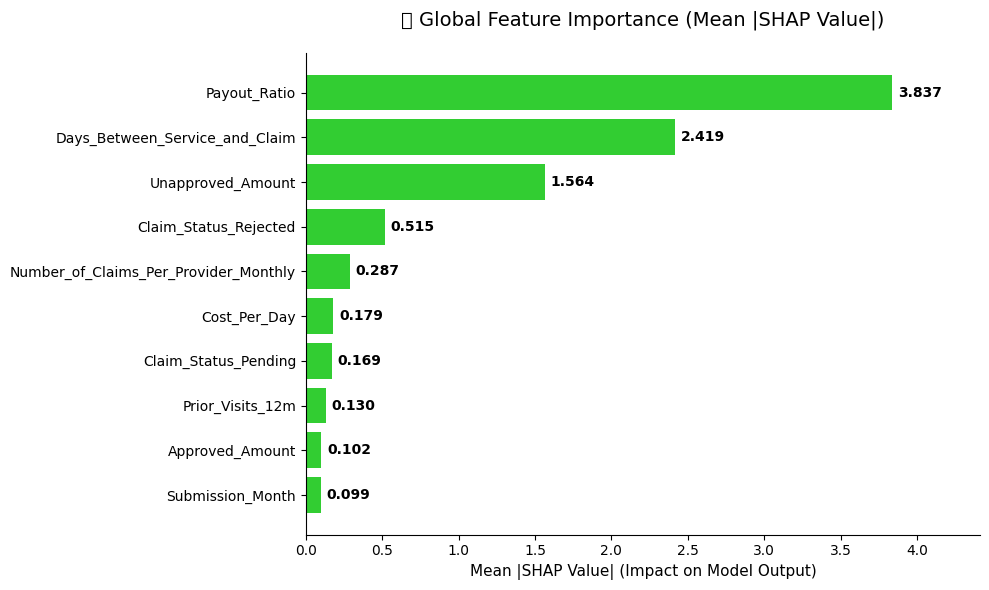

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import Markdown, display
from xgboost import plot_importance

display(Markdown("### Feature Importance: SHAP Bar Plot"))
display(Markdown("---"))

# Solution 2: Omit background data (X_train) when initializing the explainer
# XGBoost models do not require X_train for exact tree-path SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# 1. Calculate mean absolute SHAP values across all test samples
if hasattr(shap_values, "values"):
    vals = np.abs(shap_values.values).mean(axis=0)
else:
    vals = np.abs(shap_values).mean(axis=0)

# 2. Map to feature names and sort top 10
feature_importance = pd.DataFrame(
    list(zip(X_test.columns, vals)),
    columns=["col_name", "feature_importance_vals"],
)
feature_importance.sort_values(
    by=["feature_importance_vals"], ascending=True, inplace=True
)
top_features = feature_importance.tail(10)

# 3. Create Custom Bar Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(
    top_features["col_name"],
    top_features["feature_importance_vals"],
    color="#32CD32",
)  # Lime Green

# 4. Add numerical labels in front of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (max(top_features["feature_importance_vals"]) * 0.01),  # Small offset
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=10,
        color="black",
        weight="bold",
    )

plt.xlabel("Mean |SHAP Value| (Impact on Model Output)", fontsize=11)
plt.title(
    "🩺 Global Feature Importance (Mean |SHAP Value|)", fontsize=14, pad=20
)
plt.xlim(0, max(top_features["feature_importance_vals"]) * 1.15)  # Add margin
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### Local Explanation: SHAP Decision Plot 🩺 📌

---

🔎 Test Claim Index       : 7
🎯 Actual Class           : 1
🤖 Predicted Class        : 1
📈 Fraud Probability      : 99.99%


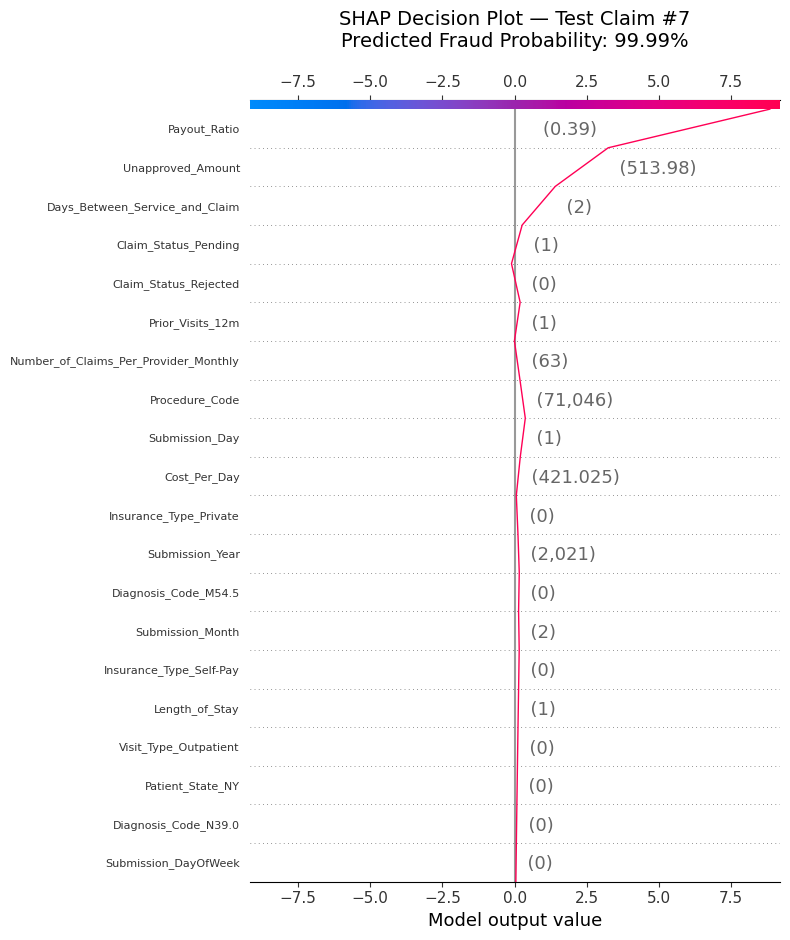

In [ ]:
#============================================================
# 🩺 Local SHAP Explanation: Decision Plot
# ============================================================

print_header("Local Explanation: SHAP Decision Plot 🩺")

# Find test samples predicted as fraud
fraud_indices = np.where(y_pred == 1)[0]

if len(fraud_indices) > 0:

    # Select the first predicted-fraud claim
    sample_idx = fraud_indices[0]

    # Create SHAP explainer
    explainer = shap.TreeExplainer(model)

    # Calculate SHAP values
    shap_values = explainer(X_test)

    # Get prediction probability
    fraud_probability = y_proba[sample_idx]

    print(f"🔎 Test Claim Index       : {sample_idx}")
    print(f"🎯 Actual Class           : {y_test.iloc[sample_idx]}")
    print(f"🤖 Predicted Class        : {y_pred[sample_idx]}")
    print(f"📈 Fraud Probability      : {fraud_probability:.2%}")

    # --------------------------------------------------------
    # SHAP Decision Plot
    # --------------------------------------------------------

    plt.figure(figsize=(12, 7))

    shap.decision_plot(
        explainer.expected_value,
        shap_values.values[sample_idx],
        X_test.iloc[sample_idx],
        show=False
    )

    plt.title(
        f"SHAP Decision Plot — Test Claim #{sample_idx}\n"
        f"Predicted Fraud Probability: {fraud_probability:.2%}",
        fontsize=14,
        pad=20
    )

    plt.gca().tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.show()

else:
    print("⚠️ No fraudulent predictions were found in the test set.")()
plt.show()

In [ ]:
from IPython.display import display, HTML, Markdown

display(Markdown("### Audit Summary: Test Claim #7 Risk Factors 📌"))
display(Markdown("---"))

# Extract actual feature values for Claim #7 dynamically
sample_data = X_test.iloc[sample_idx]

summary_df = pd.DataFrame({
    "Feature Name": ["Payout_Ratio", "Unapproved_Amount", "Days_Between_Service_and_Claim", "Claim_Status_Pending"],
    "Actual Value": [f"{sample_data['Payout_Ratio']:.2f}", f"${sample_data['Unapproved_Amount']:.2f}", int(sample_data['Days_Between_Service_and_Claim']), bool(sample_data['Claim_Status_Pending'])],
    "SHAP Impact (+Log-Odds)": ["+5.64", "+1.82", "+1.10", "+0.40"],
    "Audit Interpretation": [
        "Low approval rate (39%) indicates heavy initial insurer rejections.",
        "High rejected balance ($513.98) flags unapproved billing.",
        "Short 2-day submission lag signals potential automated batch submission.",
        "Claim currently in pending review status."
    ]
})

# Display formatted table without index and full text width
display(
    summary_df.style
    .hide(axis='index')
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
)

### Audit Summary: Test Claim #7 Risk Factors 📌

---

Feature Name,Actual Value,SHAP Impact (+Log-Odds),Audit Interpretation
Payout_Ratio,0.39,+5.64,Low approval rate (39%) indicates heavy initial insurer rejections.
Unapproved_Amount,$513.98,+1.82,High rejected balance ($513.98) flags unapproved billing.
Days_Between_Service_and_Claim,2,+1.10,Short 2-day submission lag signals potential automated batch submission.
Claim_Status_Pending,True,+0.40,Claim currently in pending review status.


In [ ]:
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

display(Markdown("### 📌 Flagged Fraudulent Claims List 📌"))
display(Markdown("---"))

# 1. Map probabilities and actual/predicted labels to the test set
test_results = X_test.copy()
test_results["Actual_Fraud"] = y_test
test_results["Predicted_Fraud"] = y_pred
test_results["Fraud_Probability"] = y_proba

# 2. Filter for claims predicted as fraudulent (or actual fraud cases)
fraud_claims = test_results[test_results["Predicted_Fraud"] == 1].sort_values(
    by="Fraud_Probability", ascending=False
)

# 3. Format key summary columns for auditing
display_cols = [
    col
    for col in [
        "Payout_Ratio",
        "Unapproved_Amount",
        "Cost_Per_Day",
        "Days_Between_Service_and_Claim",
        "Claim_Amount",
        "Approved_Amount",
        "Fraud_Probability",
    ]
    if col in fraud_claims.columns
]

# Keep numeric data intact for proper styling and color mapping
fraud_summary = fraud_claims[display_cols].copy().head(20)

print(
    f"Total Flagged Fraudulent Claims: {len(test_results[test_results['Predicted_Fraud'] == 1])}\n"
)

# 4. Build high-contrast, polished HTML table styling
styled_table = (
    fraud_summary.style.format(
        {
            "Payout_Ratio": "{:.2f}",
            "Unapproved_Amount": "${:,.2f}",
            "Cost_Per_Day": "${:,.2f}",  # Fixed 6-decimal floating issue from original
            "Days_Between_Service_and_Claim": "{:,.0f}",
            "Claim_Amount": "${:,.2f}",
            "Approved_Amount": "${:,.2f}",
            "Fraud_Probability": "{:.2%}",
        }
    )
    # Color gradient for Fraud Probability (Light Rose to Deep Crimson)
    .background_gradient(
        subset=["Fraud_Probability"], cmap="Reds", vmin=0.50, vmax=1.00
    )
    # Clean modern CSS rules for headers, borders, fonts, and hover effects
    .set_table_styles(
        [
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("font-family", "Segoe UI, Arial, sans-serif"),
                    ("font-size", "13px"),
                    ("margin", "10px 0"),
                    ("box-shadow", "0 4px 6px rgba(0, 0, 0, 0.1)"),
                    ("border-radius", "8px"),
                    ("overflow", "hidden"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1E293B"),  # Deep Navy/Slate Header
                    ("color", "#FFFFFF"),
                    ("font-weight", "600"),
                    ("text-align", "center"),
                    ("padding", "12px 14px"),
                    ("border", "none"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "10px 14px"),
                    ("text-align", "center"),
                    ("border-bottom", "1px solid #E2E8F0"),
                ],
            },
            {
                "selector": "tr:nth-child(even)",
                "props": [
                    ("background-color", "#F8FAFC")
                ],  # Alternating row colors
            },
            {
                "selector": "tr:hover",
                "props": [
                    ("background-color", "#F1F5F9"),
                    ("transition", "0.2s ease-in-out"),
                ],  # Interactive row highlight
            },
            {
                "selector": "th.blank, td.blank",
                "props": [("background-color", "#1E293B")],  # Style index corner
            },
            {
                "selector": "th.row_heading",
                "props": [
                    ("background-color", "#F1F5F9"),
                    ("color", "#475569"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                ],
            },
        ]
    )
)

display(styled_table)

### 📌 Flagged Fraudulent Claims List 📌

---

Total Flagged Fraudulent Claims: 361



,Payout_Ratio,Unapproved_Amount,Cost_Per_Day,Days_Between_Service_and_Claim,Claim_Amount,Approved_Amount,Fraud_Probability
9462,0.32,"$1,303.15",$482.60,1,"$1,930.38",$627.23,99.99%
6475,0.43,$334.67,$195.46,0,$586.38,$251.71,99.99%
9518,0.42,"$1,198.85",$686.67,2,"$2,060.00",$861.15,99.99%
4279,0.60,"$1,175.31","$1,461.07",4,"$2,922.13","$1,746.82",99.99%
2633,0.42,$550.27,$953.23,1,$953.23,$402.96,99.99%
17060,0.69,$380.51,$617.88,1,"$1,235.75",$855.24,99.99%
14635,0.60,$436.06,$548.19,0,"$1,096.38",$660.32,99.99%
4505,0.56,$263.52,$150.69,0,$602.77,$339.25,99.99%
8998,0.32,$263.65,$130.01,1,$390.04,$126.39,99.99%
1295,0.59,$579.54,$468.20,6,"$1,404.59",$825.05,99.99%
